In [17]:
import torch
import os
import sys

from src.colour_mnist import get_biased_mnist_dataloader
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor
from craft.craft_torch import Craft, torch_to_numpy

import numpy as np
import matplotlib.pyplot as plt
import random as rd
import seaborn as sb

In [28]:
exp_id = 0
exp_name = "MNIST"
batch_size = 256
data_path = os.getcwd() + "/data/MNIST"
train_correlation, test_correlation = 0.9, 0.1
epochs = 20
shuffle_seed = 56
split_gen_seed = 56

In [25]:
current_path = os.getcwd()
train_dataloader, validation_dataloader = get_biased_mnist_dataloader(root=data_path, batch_size=batch_size, data_label_correlation=train_correlation, train=True, validation=1/6, split_gen_seed=split_gen_seed, shuffle_seed=shuffle_seed)
test_dataloader = get_biased_mnist_dataloader(root=data_path, batch_size=batch_size, data_label_correlation=test_correlation, train=False)

for X, y, _ in test_dataloader:
    print(f"Shape of X [N, C, H, W]: {X.shape}")
    print(f"Shape of y: {y.shape} {y.dtype}")
    break

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using {device} device")

import src.model_utils as mu

model = mu.CMNISTNeuralNetwork().to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)
model

Shape of X [N, C, H, W]: torch.Size([256, 3, 28, 28])
Shape of y: torch.Size([256]) torch.int64
Using cuda device


CMNISTNeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (l1): Sequential(
    (0): Linear(in_features=2352, out_features=512, bias=True)
    (1): ReLU()
  )
  (l2): Sequential(
    (0): Linear(in_features=512, out_features=512, bias=True)
    (1): ReLU()
  )
  (l3): Sequential(
    (0): Linear(in_features=512, out_features=10, bias=True)
  )
)

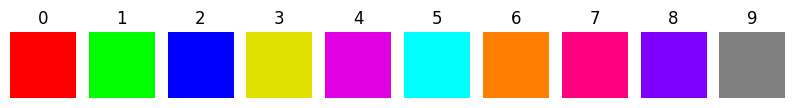

In [26]:
COLOUR_MAP = [[255, 0, 0], [0, 255, 0], [0, 0, 255], [225, 225, 0], [225, 0, 225],
                  [0, 255, 255], [255, 128, 0], [255, 0, 128], [128, 0, 255], [128, 128, 128]]
fig, axes = plt.subplots(1,10, figsize=(10,10))
for label, color in enumerate(COLOUR_MAP):
    axes[label].set_axis_off()
    axes[label].set_title(loc="center", label=f"{label}")
    axes[label].imshow([[color]])

In [5]:
def train(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    model.train()
    for batch, (X, y, _) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)

        # Compute prediction error
        pred = model(X)
        loss = loss_fn(pred, y)

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        if (batch *batch_size)% 100 == 0:
            loss, current = loss.item(), (batch + 1) * len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")


def test(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    test_loss, correct = 0, 0
    appearance_matrix = []
    correctness_matrix = None
    with torch.no_grad():
        for X, y, y_pred in dataloader:
            X, y, y_pred = X.to(device), y.to(device), y_pred.to(device)
            pred = model(X)
            if len(appearance_matrix)==0:
                size_y = len(pred[0])
                appearance_matrix = np.array([[0 for i in range(size_y)] for j in range(size_y)])
                correctness_matrix = np.array([[0 for i in range(size_y)] for j in range(size_y)])
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()
            for i in range(size_y):
                for j in range(size_y):
                    appearance_matrix[i][j] += int(((y==i) & (y_pred==j)).sum())
                    correctness_matrix[i][j] += int((pred.argmax(1)[((y==i) & (y_pred==j))] == i).sum())
    test_loss /= num_batches
    correct /= size
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")
    accuracy_matrix = correctness_matrix/appearance_matrix
    return accuracy_matrix

accuracy_matrixes = []
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train(train_dataloader, model, loss_fn, optimizer)
    accuracy_matrixes.append(test(test_dataloader, model, loss_fn))
print("Done!")

torch.save(model.state_dict(), f"models/{exp_name}_model_{exp_id}_{epochs}_{train_correlation}")
print("Saved under" + f"models/{exp_name}_model_{exp_id}_{epochs}_{train_correlation}")

Epoch 1
-------------------------------
loss: 2.305512  [  256/50000]
loss: 0.631951  [ 6656/50000]
loss: 0.396734  [13056/50000]
loss: 0.267891  [19456/50000]
loss: 0.300250  [25856/50000]
loss: 0.209795  [32256/50000]
loss: 0.199796  [38656/50000]
loss: 0.154995  [45056/50000]
Test Error: 
 Accuracy: 61.9%, Avg loss: 1.129942 

Epoch 2
-------------------------------
loss: 0.218346  [  256/50000]
loss: 0.111169  [ 6656/50000]
loss: 0.149151  [13056/50000]
loss: 0.089993  [19456/50000]
loss: 0.180630  [25856/50000]
loss: 0.111667  [32256/50000]
loss: 0.237943  [38656/50000]
loss: 0.164848  [45056/50000]
Test Error: 
 Accuracy: 73.4%, Avg loss: 0.796039 

Epoch 3
-------------------------------
loss: 0.095114  [  256/50000]
loss: 0.200003  [ 6656/50000]
loss: 0.116551  [13056/50000]
loss: 0.105152  [19456/50000]
loss: 0.122104  [25856/50000]
loss: 0.178622  [32256/50000]
loss: 0.145046  [38656/50000]
loss: 0.156786  [45056/50000]
Test Error: 
 Accuracy: 75.6%, Avg loss: 0.761415 

Epoc

/tmp/ipykernel_3334/42919964.py:7: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  img = np.array(img)


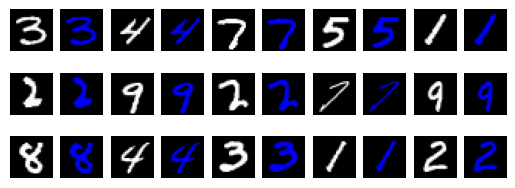

In [29]:
from src.colour_mnist import get_bias_difference_mnist_dataloader
dif_train, dif_val = get_bias_difference_mnist_dataloader(root=data_path, batch_size=batch_size, train=True, validation=1/6, split_gen_seed=split_gen_seed, shuffle_seed=shuffle_seed, bias_colour=2)

import matplotlib.pyplot as plt
from math import ceil
def show(img, **kwargs):
    img = np.array(img)
    if img.shape[0] == 3:
        img = img.transpose(1, 2, 0)

    img -= img.min();img /= img.max()
    plt.imshow(img, **kwargs); plt.axis('off')

for i, (X1, X2, _) in enumerate(dif_val):
    k = 1
    for j in range(len(X1)):
        plt.subplot(6, 10, k)
        show(X1[j])
        plt.subplot(6, 10, k+1)
        show(X2[j])
        k +=2
        if k > 30:
            break
    break
plt.show()

/tmp/ipykernel_21917/3094987044.py:4: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  img = np.array(img)


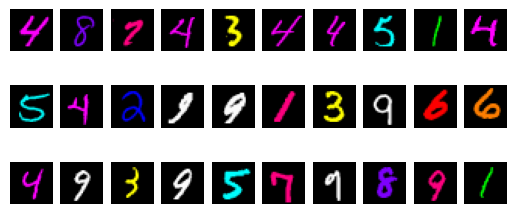

In [6]:
import matplotlib.pyplot as plt
from math import ceil
def show(img, **kwargs):
    img = np.array(img)
    if img.shape[0] == 3:
        img = img.transpose(1, 2, 0)

    img -= img.min();img /= img.max()
    plt.imshow(img, **kwargs); plt.axis('off')

for i, (X, y, _) in enumerate(train_dataloader):
    k = 1
    for img in X:
        plt.subplot(5, 10, k)
        show(img)
        k +=1
        if k > 30:
            break
    break
plt.show()

<Axes: >

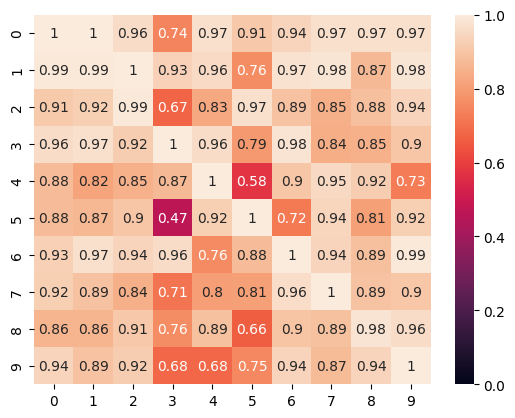

In [6]:
sb.heatmap(accuracy_matrixes[-1], vmin=0, vmax=1, annot=True)